In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
import os

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
#from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el

import pyccl as ccl

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)


## 1. Define Cosmology

In [2]:
cosmo_dict = {
    'H0': 67.7,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'Omega_k':0,
    'omch2': 0.25*0.677**2,
    'ombh2': 0.05*0.677**2,
    'w0': -1,
    'wa':0,
    'ns':0.95,
    'As':2e-9,
    'mnu':0.0,
    'nnu':3.044,
    'Neff':3.044,
    'halofit_version':'mead2020'
}

zs = np.linspace(1e-4, 3., 256) #256 is the maximum allowed by CAMB


## 2. Compute and compare Power Spectra

### 2.1. CAMB 

In [3]:
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

pars = camb.set_params(H0=cosmo_dict['H0'], 
                       ombh2=cosmo_dict['ombh2'],
                       omch2=cosmo_dict['omch2'], 
                       mnu=cosmo_dict['mnu'],
                       nnu=cosmo_dict['nnu'],
                       standard_neutrino_neff=cosmo_dict['Neff'], 
                       omk=cosmo_dict['Omega_k'],  
                       As=cosmo_dict['As'],
                       ns=cosmo_dict['ns'], 
                       halofit_version=cosmo_dict['halofit_version'],
                       tau = 0.07
                       )

pars.set_matter_power(redshifts=zs, kmax=100) 

# Linear P(k)
results = camb.get_results(pars)
ks = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False,)[0]
pk_lin_camb = results.get_matter_power_interpolator(nonlinear=False, hubble_units=False, k_hunit=False).P(0,ks)

# Non linear P(k)
pk_nonlin_camb = results.get_matter_power_interpolator(nonlinear=True, hubble_units=False, k_hunit=False).P(0,ks)

Using CAMB 1.5.9 installed at /Users/jcoloma/miniconda3/envs/envCLOE/lib/python3.10/site-packages/camb
Note: redshifts have been re-sorted (earliest first)


### 2.2 CLOE 

In [4]:
background = CAMBBackground(H0 = cosmo_dict['H0'], 
                            Omega_cdm0 = cosmo_dict['Omega_c'], 
                            Omega_b0 = cosmo_dict['Omega_b'], 
                            w0 = cosmo_dict['w0'], 
                            wa = cosmo_dict['wa'], 
                            Omega_k0 = cosmo_dict['Omega_k'], 
                            ns = cosmo_dict['ns'], 
                            As = cosmo_dict['As'],
                            mnu = cosmo_dict['mnu'],
                            gamma_MG=0
                            )

linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_lin_cloe = linear_perturbations.matter_power_spectrum(0, ks) #(z, k)

nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = cosmo_dict['halofit_version']) 
pk_nonlin_cloe = nonlinear_perturbations.matter_power_spectrum(0, ks)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


### 2.3. CCL 

In [5]:
cosmo = ccl.Cosmology(h = cosmo_dict['H0']/100,
                      Omega_c = cosmo_dict['Omega_c'],
                      Omega_b = cosmo_dict['Omega_b'],
                      m_nu = cosmo_dict['mnu'],
                      Neff = cosmo_dict['Neff'], 
                      w0 = cosmo_dict['w0'],
                      wa = cosmo_dict['wa'],
                      Omega_k = cosmo_dict['Omega_k'],
                      n_s = cosmo_dict['ns'], 
                      A_s = cosmo_dict['As'],
                      matter_power_spectrum = 'camb', # linear / halofit / camb ...
                      extra_parameters = {'camb':{"halofit_version": cosmo_dict['halofit_version']}}, #    "HMCode_logT_AGN": 7.8} })
                      transfer_function='boltzmann_camb', # bbks / boltmann_class/_camb ...
                      T_ncdm=0
                      )

pk_values_ccl = ccl.boltzmann.get_camb_pk_lin(cosmo, nonlin=True ) 
pk_lin_ccl = pk_values_ccl[0](ks, 1) # (k, a)
pk_nonlin_ccl = pk_values_ccl[1](ks, 1) 

### 2.4. Compare P(k)'s

#### 2.4.1. Linear P(k)

/Users/jcoloma/miniconda3/envs/envCLOE/lib/python3.10/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


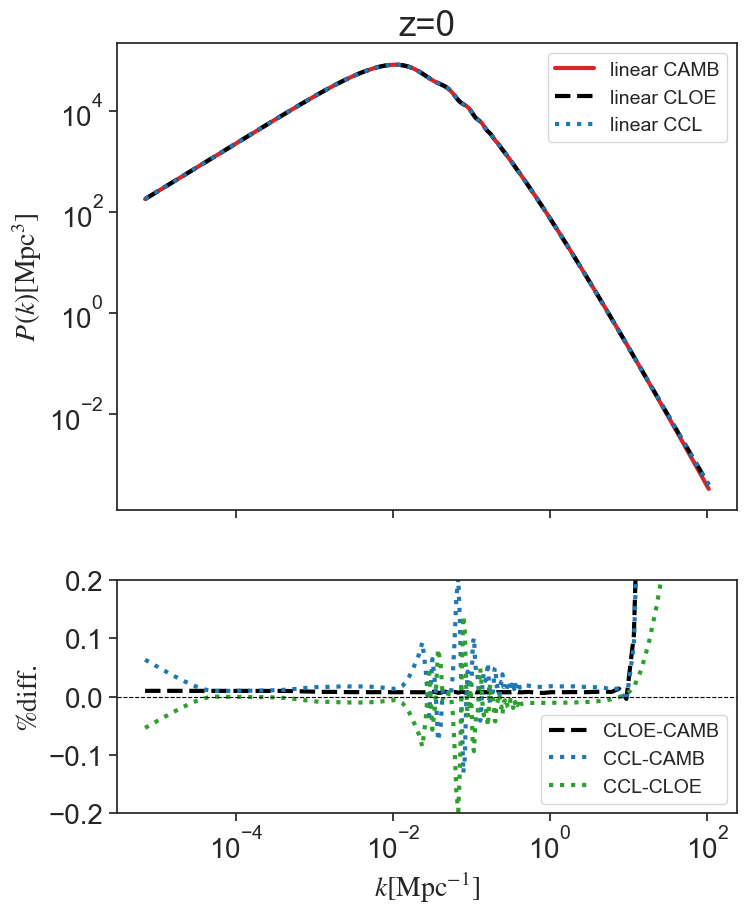

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title('z=0')
axs[0].set_ylabel(r'$P_{\rm}(k) [\rm{Mpc}^3]$')
axs[0].loglog(ks,  pk_lin_camb, color='tab:red',  label='linear CAMB')
axs[0].loglog(ks,  pk_lin_cloe, color='black', ls='--', label='linear CLOE')
axs[0].loglog(ks,  pk_lin_ccl, color='tab:blue', ls=':', label='linear CCL')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k [\rm{Mpc}^{-1}]$')
axs[1].set_ylabel(r'$\% \rm{diff.}$')    #(r'$\frac{P_{}(k) - P_{\rm CLOE}(k)}{P_{\rm CCL}(k)}\times 100$')
axs[1].plot(ks, (pk_lin_cloe - pk_lin_camb)/pk_lin_camb*100, color='black', ls='--', label='CLOE-CAMB')
axs[1].plot(ks, (pk_lin_ccl - pk_lin_camb)/pk_lin_camb*100, color='tab:blue', ls=':', label='CCL-CAMB')
axs[1].plot(ks, (pk_lin_cloe - pk_lin_ccl)/pk_lin_cloe*100, color='tab:green', ls=':', label='CCL-CLOE')

axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_ylim([-0.2, 0.2])
axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')



#### 2.4.2. Non-linear P(k)

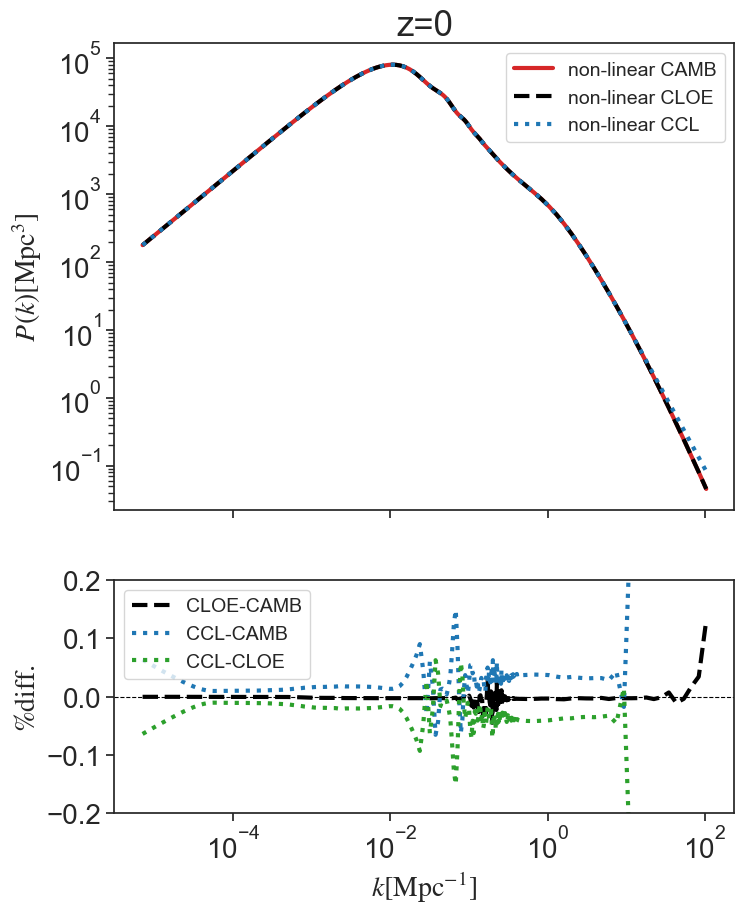

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title('z=0')
axs[0].set_ylabel(r'$P_{\rm}(k) [\rm{Mpc}^3]$')
axs[0].loglog(ks,  pk_nonlin_camb, color='tab:red',  label='non-linear CAMB')
axs[0].loglog(ks,  pk_nonlin_cloe, color='black', ls='--', label='non-linear CLOE')
axs[0].loglog(ks,  pk_nonlin_ccl, color='tab:blue', ls=':', label='non-linear CCL')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k [\rm{Mpc}^{-1}]$')
axs[1].set_ylabel(r'$\% \rm{diff.}$')    #(r'$\frac{P_{\rm CCL}(k) - P_{\rm CLOE}(k)}{P_{\rm CCL}(k)}\times 100$')
axs[1].plot(ks, (pk_nonlin_cloe - pk_nonlin_camb)/pk_nonlin_camb*100, color='black', ls='--', label='CLOE-CAMB')
axs[1].plot(ks, (pk_nonlin_ccl - pk_nonlin_camb)/pk_nonlin_camb*100, color='tab:blue', ls=':', label='CCL-CAMB')
axs[1].plot(ks, (pk_nonlin_cloe - pk_nonlin_ccl)/pk_nonlin_cloe*100, color='tab:green', ls=':', label='CCL-CLOE')

axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_ylim([-0.2, 0.2])
axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

## 3. Redshift distributions

### 3.1. Heracles
Files at: https://zenodo.org/records/15092862/files/nz_example.fits

In [8]:
z, nz_heracles = el.photo.redshift_distributions('/Users/jcoloma/phd/ice/cloe-org/cloelib/notebooks/data/nz_example_heracles.fits')

# Normalise dndz
dndz_pos_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_pos_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)

dndz_she_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_she_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)


# Resampling the normalized n(z) with len(zs)=256 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
dndz_pos = np.zeros([len(nz_heracles.keys()), len(zs)])
for i in range(6):
    dndz_pos[i,:] = np.interp(zs, z, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
dndz_she = np.zeros([len(nz_heracles.keys()), len(zs)])
for i in range(6):
    dndz_she[i,:] = np.interp(zs, z, my_dndz_she[i,:])



### 3.2. Plot dndz's

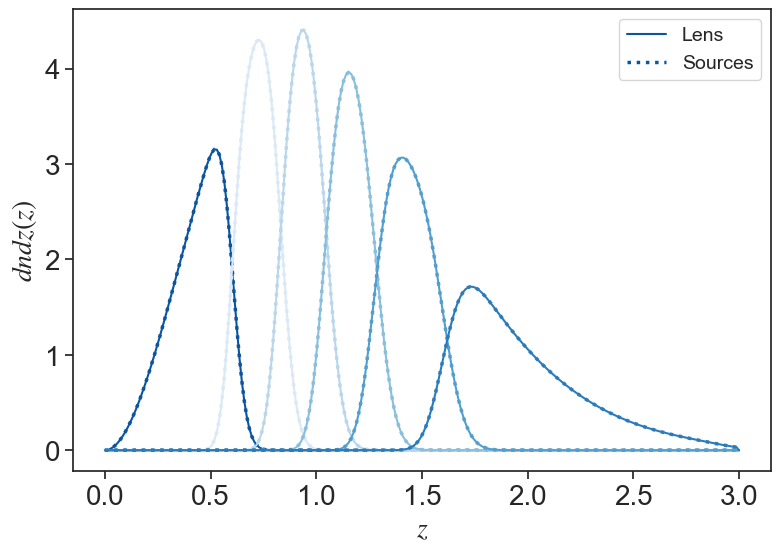

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(9,6))

axs.set_ylabel(r'$dndz(z)$')
axs.set_xlabel(r'$z$')

for i in range(6):
    if i==0:
        axs.plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1], label = 'Lens')
        axs.plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1], label = 'Sources')

    else:
        axs.plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1])
        axs.plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1])


axs.legend()



## 4. Tracers

### 4.1. CLOE

In [10]:
tracer_pos_cloe = PositionsTracer(perturbations=nonlinear_perturbations, 
                            dndz=dndz_pos,
                            z=zs,
                            galaxy_bias_model='per_bin',
                            nuisance_params={'b1_photo_bin1': 1.0, 'b1_photo_bin2': 1.0, 'b1_photo_bin3': 1.0, 'b1_photo_bin4': 1.0,
                                             'b1_photo_bin5': 1.0, 'b1_photo_bin6': 1.0}

                            )

tracer_she_cloe = ShearTracer(perturbations=nonlinear_perturbations, 
                            dndz=dndz_she,
                            z=zs,
                            nuisance_params={'AIA': 0.0, 'CIA': 0.0, 'EtaIA':0.0})  

### 4.2. CCL

In [11]:
bias_array = np.ones(len(zs))                                 
tracer_pos_ccl = {}
tracer_pos_ccl_norm = {}
tracer_she_ccl = {}
tracer_she_ccl_norm = {}
for i in range(6):
    tracer_pos_ccl[str(i)] = ccl.NumberCountsTracer(cosmo, 
                                    has_rsd=False,
                                    dndz=(zs, dndz_pos[i]), 
                                    bias=(zs, bias_array))
    


    tracer_she_ccl[str(i)] = ccl.WeakLensingTracer(cosmo, 
                                        dndz=(zs, dndz_she[i]),
                                        ia_bias=None, use_A_ia=False 
                                       )




### 4.3. Compare window functions

bin (1,1) | Window %diff. = 6.943489968699291e-05 %
bin (2,2) | Window %diff. = 0.0001530087288659664 %
bin (3,3) | Window %diff. = 2.16898568622083e-05 %
bin (4,4) | Window %diff. = -0.00010115490819998962 %
bin (5,5) | Window %diff. = 1.1116552996015794e-05 %
bin (6,6) | Window %diff. = 0.0009205133260832452 %


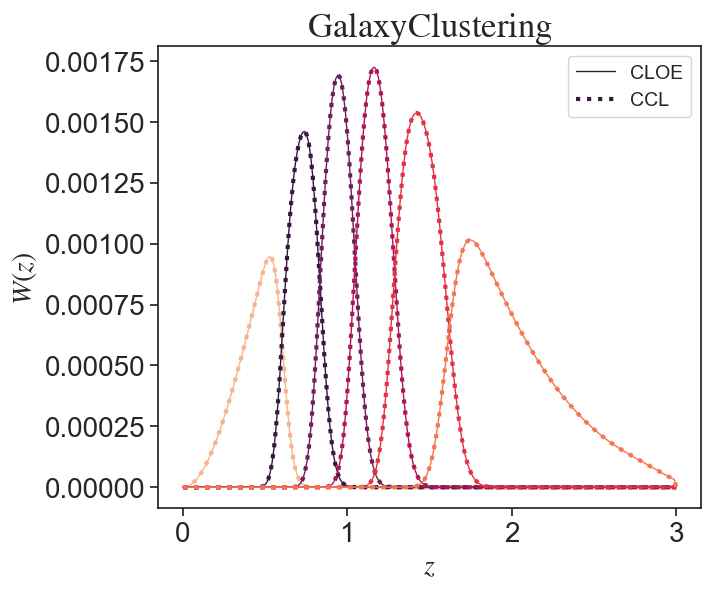

In [12]:
probe = 'pos' # pos o she
if probe=='pos':
    title = r'$\rm{Galaxy Clustering}$'
else:
    title = r'$\rm{Weak Lensing}$'

window_cloe = globals()[f'tracer_{probe}_cloe']
window_ccl = globals()[f'tracer_{probe}_ccl']
#z_dr1 = globals()[f'z_{probe}_dr1']
dc = results.comoving_radial_distance(zs)

fig, axs = plt.subplots(1, 1, figsize=(7,6), sharex=True)

axs.set_ylabel(r'$W(z)$')
axs.set_xlabel(r'$z$')

for i in range(6):
    if i==1:
        axs.plot(zs, window_cloe.get_window(zs)[i,:], linewidth=1, color=sns.color_palette("rocket", 6)[i-1], label = r'CLOE')
        axs.plot(zs, window_ccl[str(i)].get_kernel(dc)[0], ls=':', color=sns.color_palette("rocket", 6)[i-1], label = r'CCL')
    else:
        axs.plot(zs, window_cloe.get_window(zs)[i,:], linewidth=1, color=sns.color_palette("rocket", 6)[i-1])
        axs.plot(zs, window_ccl[str(i)].get_kernel(dc)[0], ls=':', color=sns.color_palette("rocket", 6)[i-1])


#axs[1].set_ylim([0, .3])

axs.legend(fontsize=14)
axs.set_title(title)


# (Squared) Area differences 
for i in range(6):
    w_cloe = window_cloe.get_window(zs)[i,:]
    w_ccl = window_ccl[str(i)].get_kernel(dc)[0]
    A_cloe = np.trapz(w_cloe**2)
    A_ccl = np.trapz(w_ccl**2)
    print('bin ('+str(i+1)+','+str(i+1)+')','|', 'Window %diff. =', (A_cloe-A_ccl)/A_ccl*100, '%')

## 5. Angular Power Spectra

### 5.1. CLOE

In [13]:
nl = 100
ells = np.logspace(1., np.log10(3000.), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
twopoint_shepos = AngularTwoPoint(tracer_she_cloe, tracer_pos_cloe)
twopoint_sheshe = AngularTwoPoint(tracer_she_cloe, tracer_she_cloe)

cells_GG_cloe = twopoint_pospos.get_Cl(ells, nl, ks)
cells_GGL_cloe = twopoint_shepos.get_Cl(ells, nl, ks)
cells_EE_cloe = twopoint_sheshe.get_Cl(ells, nl, ks)

### 5.2. CCL

In [14]:
#Limber prefactors
lf_dl=(ells+0.5)**2/np.sqrt((ells+2.)*(ells+1.)*ells*(ells-1.))
lf_ll=ells*(ells+1.)/np.sqrt((ells+2.)*(ells+1.)*ells*(ells-1.))
    
#CCL Power spectra
cells_GG_ccl={}
cells_GGL_ccl={}
cells_EE_ccl={}
for i in range(6):
    cells_GG_ccl[str(i)] = ccl.angular_cl(cosmo, tracer_pos_ccl[str(i)], tracer_pos_ccl[str(i)], ells)
    cells_GGL_ccl[str(i)] = ccl.angular_cl(cosmo, tracer_she_ccl[str(i)], tracer_pos_ccl[str(i)], ells)
    cells_EE_ccl[str(i)] = ccl.angular_cl(cosmo, tracer_she_ccl[str(i)], tracer_she_ccl[str(i)], ells)

### 5.3. Comparison

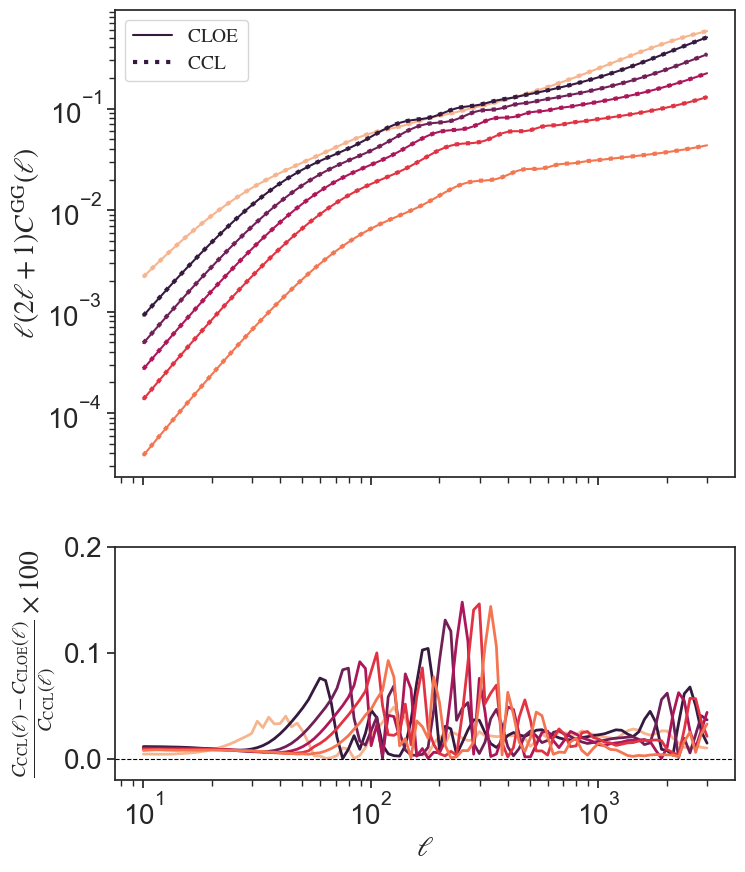

In [32]:
probe = 'GG' # 'EE'
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_ccl = globals()[f'cells_{probe}_ccl']

fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$')
axs[1].set_xlabel(r'$\ell$')
axs[1].set_ylabel(r'$\frac{C_{\rm CCL}(\ell) - C_{\rm CLOE}(\ell)}{C_{\rm CCL}(\ell)} \times 100$')

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=sns.color_palette("rocket", 6)[i-1], linewidth=1.5, label = r'$\rm{CLOE}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[str(i)], color=sns.color_palette("rocket", 6)[i-1], ls=':', linewidth=3, label = r'$\rm{CCL}$')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], linewidth=1.5, color=sns.color_palette("rocket", 6)[i-1])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[str(i)], ls=':', linewidth=3, color=sns.color_palette("rocket", 6)[i-1])

    axs[1].plot(ells, abs((cells_ccl[str(i)] - cells_cloe[:, i, i]))/cells_ccl[str(i)]*100, linewidth=2, color=sns.color_palette("rocket", 6)[i-1])

axs[1].set_ylim([-0.02, 0.2])
axs[0].legend(fontsize=14)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')


#axs[0].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
#axs[0].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)



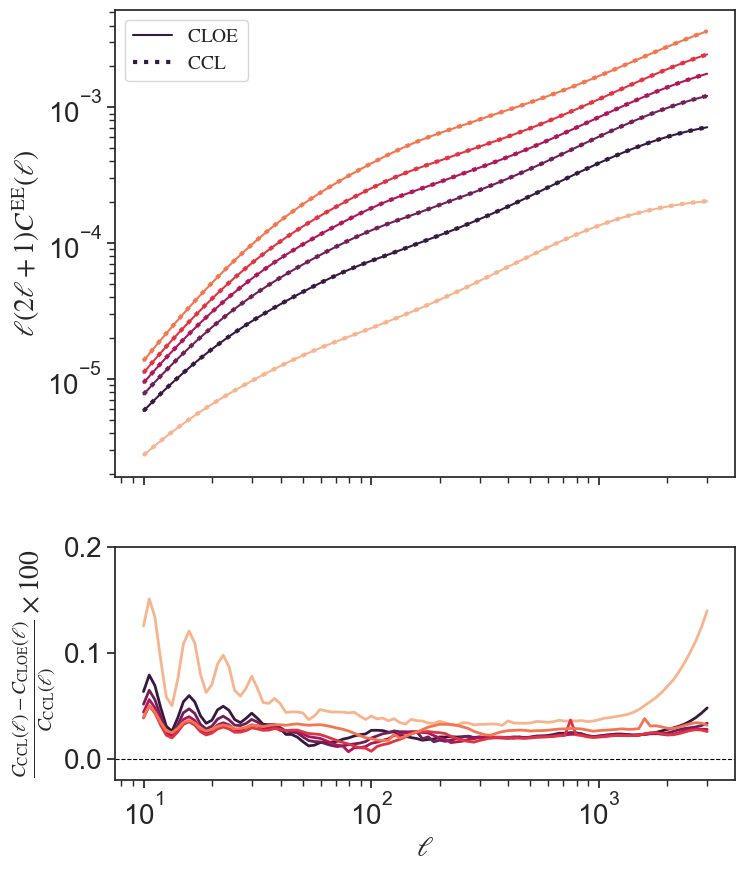

In [34]:
probe = 'EE' 
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_ccl = globals()[f'cells_{probe}_ccl']

fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$')
axs[1].set_xlabel(r'$\ell$')
axs[1].set_ylabel(r'$\frac{C_{\rm CCL}(\ell) - C_{\rm CLOE}(\ell)}{C_{\rm CCL}(\ell)} \times 100$')

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=sns.color_palette("rocket", 6)[i-1], linewidth=1.5, label = r'$\rm{CLOE}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[str(i)], color=sns.color_palette("rocket", 6)[i-1], ls=':', linewidth=3, label = r'$\rm{CCL}$')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], linewidth=1.5, color=sns.color_palette("rocket", 6)[i-1])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[str(i)], ls=':', linewidth=3, color=sns.color_palette("rocket", 6)[i-1])

    axs[1].plot(ells, abs((cells_ccl[str(i)] - cells_cloe[:, i, i]))/cells_ccl[str(i)]*100, linewidth=2, color=sns.color_palette("rocket", 6)[i-1])

axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')
axs[1].set_ylim([-0.02, 0.2])
axs[0].legend(fontsize=14)

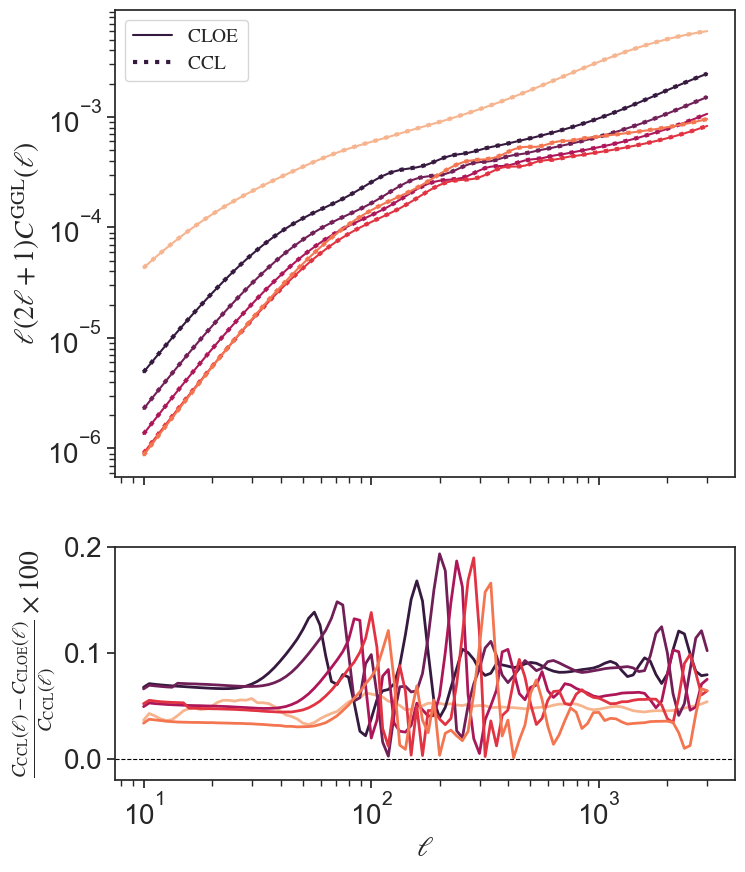

In [36]:
probe = 'GGL' # 'EE'
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_ccl = globals()[f'cells_{probe}_ccl']

fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$')
axs[1].set_xlabel(r'$\ell$')
axs[1].set_ylabel(r'$\frac{C_{\rm CCL}(\ell) - C_{\rm CLOE}(\ell)}{C_{\rm CCL}(\ell)} \times 100$')

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=sns.color_palette("rocket", 6)[i-1], linewidth=1.5, label = r'$\rm{CLOE}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[str(i)], color=sns.color_palette("rocket", 6)[i-1], ls=':', linewidth=3, label = r'$\rm{CCL}$')
    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], linewidth=1.5, color=sns.color_palette("rocket", 6)[i-1])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_ccl[str(i)], ls=':', linewidth=3, color=sns.color_palette("rocket", 6)[i-1])

    axs[1].plot(ells, abs((cells_ccl[str(i)] - cells_cloe[:, i, i]))/cells_ccl[str(i)]*100, linewidth=2, color=sns.color_palette("rocket", 6)[i-1])

axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')
axs[1].set_ylim([-0.02, 0.2])
axs[0].legend(fontsize=14)

